# Introduction to Clustering

Clustering is an unsupervised learning technique in which similar data points are grouped together.

In clustering:
- We do not have output labels
- The model finds hidden groups by itself

## Example
If we have customer data, clustering can group customers with similar behavior.

# What is K-Means?

K-Means is a clustering algorithm that divides data into K clusters.

## Main Idea
It uses the **mean (average)** of points in a cluster as the center.

That center is called **centroid**.

## Steps of K-Means
1. Choose K clusters
2. Select initial centroids
3. Assign points to nearest centroid
4. Recalculate centroids
5. Repeat until clusters become stable

# What is K-Medoids?

K-Medoids is a clustering algorithm similar to K-Means.

## Main Idea
It uses an **actual data point** as the center of a cluster.

That center is called **medoid**.

## Steps of K-Medoids
1. Choose K medoids
2. Assign points to nearest medoid
3. Check if another real point is better as medoid
4. Replace medoid if needed
5. Repeat until stable

# K-Means vs K-Medoids

| Feature | K-Means | K-Medoids |
|---------|---------|-----------|
| Center | Mean (average) | Actual data point |
| Speed | Faster | Slower |
| Outliers | Sensitive | More robust |
| Best for | Clean data | Noisy data |

## Memory Trick
- K-Means = Mean
- K-Medoids = Medoid = Real point

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

# Step 1: Create Sample Dataset

We create a simple dataset using `make_blobs()`.

## Why?
Because clustered sample data helps us clearly understand both algorithms.

In [2]:
# Create dataset

X, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.2, random_state=42)

print("Shape of dataset:", X.shape)
print("First 5 points:\n", X[:5])

Shape of dataset: (200, 2)
First 5 points:
 [[ 6.87880825  2.54176919]
 [-5.65289175 10.00056913]
 [-6.89432332 -7.95681484]
 [-8.6173284  -8.56906612]
 [-7.5868649  -5.86058708]]


In [3]:
# Convert to DataFrame for better understanding

df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
df.head()

,Feature_1,Feature_2
0,6.878808,2.541769
1,-5.652892,10.000569
2,-6.894323,-7.956815
3,-8.617328,-8.569066
4,-7.586865,-5.860587


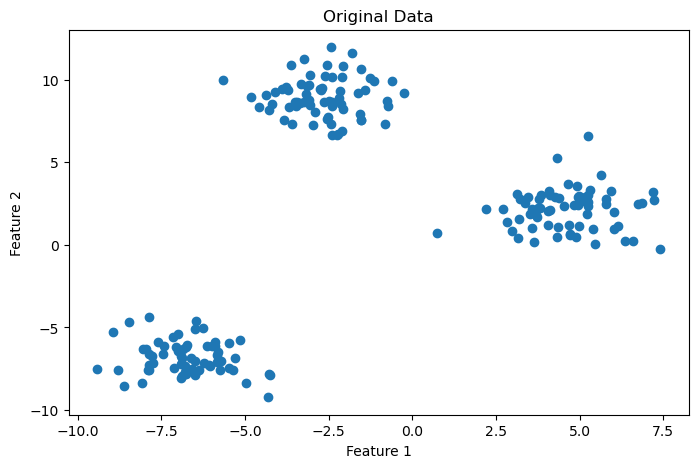

In [4]:
# Plot original data

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Program Understanding: Dataset

In this program:
- We created 200 data points
- Data is spread around 3 centers
- Each point has 2 features

This data is useful for clustering because similar points naturally form groups.

# Practical Implementation: K-Means

Now we apply K-Means clustering.

## Goal
To divide the dataset into 3 clusters using centroids.

In [5]:
# Apply K-Means

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

print("First 10 cluster labels from K-Means:")
print(labels_kmeans[:10])

First 10 cluster labels from K-Means:
[2 0 1 1 1 1 0 1 2 1]


c:\Users\saksh\anaconda3_new\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
# Print centroids

print("Centroids of K-Means:")
print(kmeans.cluster_centers_)

Centroids of K-Means:
[[-2.68874602  8.94622463]
 [-6.71854713 -6.84571013]
 [ 4.63064296  2.12682259]]


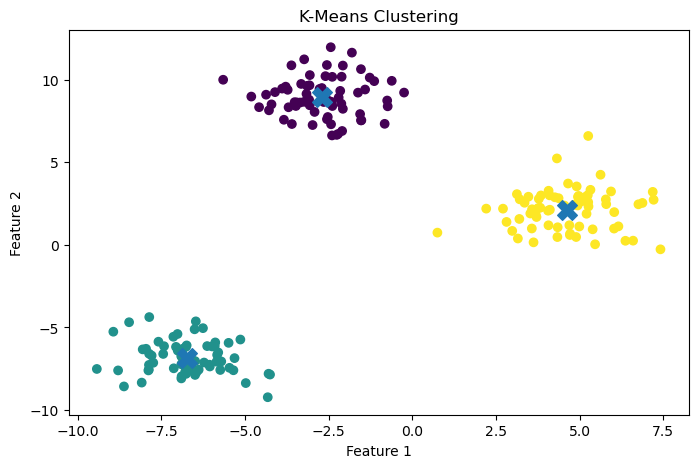

In [7]:
# Plot K-Means clusters

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200
)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Program Explanation: K-Means

In this code:
- `KMeans(n_clusters=3)` creates a K-Means model
- `fit_predict(X)` trains the model and gives cluster labels
- `cluster_centers_` returns centroid positions

## Important Point
The centroid is an average value, so it may not be an actual point from the dataset.

# K-Means Result Understanding

In the graph:
- Same color points belong to the same cluster
- X marks are centroids
- Each point is placed in the cluster of the nearest centroid

K-Means works well when clusters are round and clean.

# Practical Implementation: K-Medoids

Now we implement K-Medoids practically.

## Goal
To divide the dataset into 3 clusters using real data points as centers.

## Important Note
K-Medoids is not available in basic scikit-learn.

So here we implement a simple K-Medoids algorithm manually.

In [8]:
# Function to assign each point to nearest medoid

def assign_points_to_medoids(X, medoid_indices):
    medoids = X[medoid_indices]
    distances = pairwise_distances(X, medoids, metric="euclidean")
    labels = np.argmin(distances, axis=1)
    return labels

In [9]:
# Function to update medoids

def update_medoids(X, labels, k):
    new_medoid_indices = []

    for cluster_id in range(k):
        cluster_points_indices = np.where(labels == cluster_id)[0]
        cluster_points = X[cluster_points_indices]

        # Distance matrix inside cluster
        distances = pairwise_distances(cluster_points, cluster_points, metric="euclidean")

        # Total distance from each point to all others
        total_distances = distances.sum(axis=1)

        # Best medoid = point with minimum total distance
        best_index_in_cluster = np.argmin(total_distances)
        best_medoid_index = cluster_points_indices[best_index_in_cluster]

        new_medoid_indices.append(best_medoid_index)

    return np.array(new_medoid_indices)

In [10]:
# Simple K-Medoids algorithm

def k_medoids(X, k, max_iter=100, random_state=42):
    np.random.seed(random_state)

    # Step 1: choose random medoids
    medoid_indices = np.random.choice(len(X), size=k, replace=False)

    for _ in range(max_iter):
        # Step 2: assign points to nearest medoid
        labels = assign_points_to_medoids(X, medoid_indices)

        # Step 3: update medoids
        new_medoid_indices = update_medoids(X, labels, k)

        # Step 4: stop if medoids do not change
        if np.array_equal(medoid_indices, new_medoid_indices):
            break

        medoid_indices = new_medoid_indices

    return medoid_indices, labels

In [11]:
# Apply K-Medoids

medoid_indices, labels_kmedoids = k_medoids(X, k=3)

print("Medoid indices:")
print(medoid_indices)

print("\nMedoid points:")
print(X[medoid_indices])

Medoid indices:
[ 84 168  74]

Medoid points:
[[-6.76323203 -6.16592116]
 [-6.54243695 -7.62734902]
 [-0.82584445  7.33206485]]


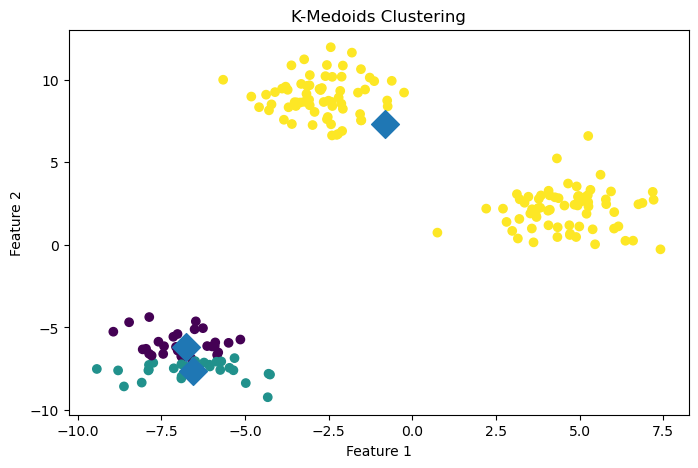

In [12]:
# Plot K-Medoids clusters

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_kmedoids)
plt.scatter(
    X[medoid_indices, 0],
    X[medoid_indices, 1],
    marker='D',
    s=200
)
plt.title("K-Medoids Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Program Explanation: K-Medoids

In this code:
- We first choose random medoids
- Each point is assigned to nearest medoid
- Then for each cluster, we choose the real point with minimum total distance
- That point becomes the new medoid
- Process repeats until medoids stop changing

## Important Point
A medoid is always an actual point from the dataset.

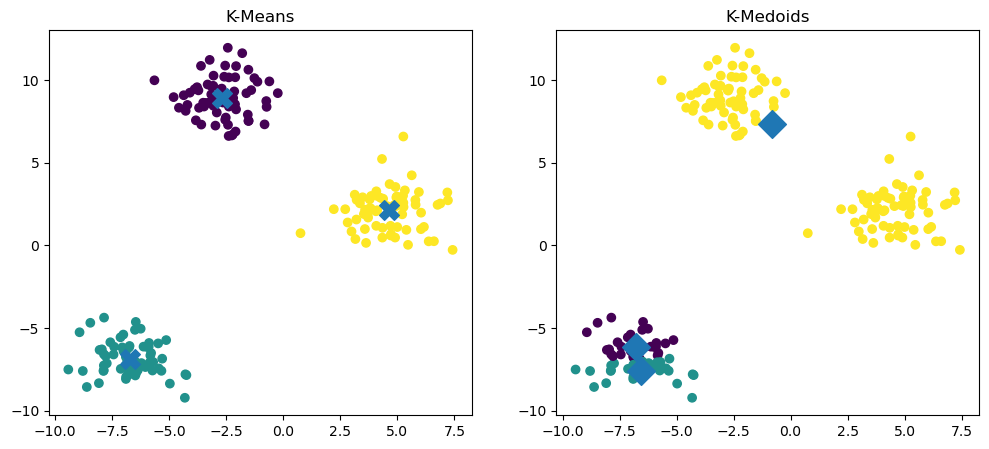

In [13]:
# Plot K-Means and K-Medoids side by side

plt.figure(figsize=(12, 5))

# K-Means
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200
)
plt.title("K-Means")

# K-Medoids
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_kmedoids)
plt.scatter(
    X[medoid_indices, 0],
    X[medoid_indices, 1],
    marker='D',
    s=200
)
plt.title("K-Medoids")

plt.show()

# Short Comparison Notes

## K-Means
- Faster
- Uses average
- Sensitive to outliers

## K-Medoids
- Slower
- Uses actual data points
- More robust to outliers

# Example to Understand Difference

Suppose one cluster has points:
- (2, 3)
- (3, 4)
- (4, 5)

## K-Means center
May be average = (3, 4)

## K-Medoids center
Must be one of the actual points:
- (2, 3) or (3, 4) or (4, 5)

So K-Medoids always chooses a real point.

# Advantages of K-Means

1. Simple and easy to understand
2. Fast for large datasets
3. Easy to implement
4. Works well on well-separated data

# Disadvantages of K-Means

1. Sensitive to outliers
2. Need to choose K in advance
3. Centroid may not be a real data point
4. Not suitable for irregular cluster shapes

# Advantages of K-Medoids

1. Uses real data points as centers
2. More robust to outliers
3. Better for noisy data
4. Easier to interpret center point

# Disadvantages of K-Medoids

1. Slower than K-Means
2. More computational cost
3. Less suitable for very large datasets
4. Manual implementation is more complex